In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity

import jax
from darnax.modules.conv.conv import Conv2D, Conv2DRecurrentDiscrete
from darnax.modules.conv.pooling import GlobalUnpooling, GlobalMajorityPooling
from darnax.modules.fully_connected import FullyConnected, FrozenRescaledFullyConnected
from darnax.modules.recurrent import RecurrentDiscrete
from darnax.modules.input_output import OutputLayer


from darnax.layer_maps.sparse import LayerMap
from darnax.states.sequential import SequentialState
from darnax.orchestrators.sequential import SequentialOrchestrator
from darnax.datasets.classification.cifar10 import Cifar10

import equinox as eqx
import jax.tree_util as jtu
import optax
import jax.numpy as jnp


## Importing the dataset (CIFAR)

In [2]:
data = Cifar10(
    batch_size=32,
    linear_projection=None,
    label_mode="pm1",
    x_transform="identity",
)

key = jax.random.PRNGKey(0)
key, data_key = jax.random.split(key)

data.build(key=data_key)

Array([2566685366, 2716172981], dtype=uint32)

In [ ]:
x, y = next(iter(data))
print(f"Data shape: x={x.shape}, y={y.shape}")
print(f"Expected: x=(batch, 32, 32, 3), got x={x.shape}")

# If flattened, reshape it back
if x.ndim == 2:
    x = x.reshape(x.shape[0], 32, 32, 3)
    print(f"Reshaped x to: {x.shape}")

x = (x - x.mean()) / x.std()

Data shape: x=(32, 3072), y=(32, 10)
Expected: x=(batch, 32, 32, 3), got x=(32, 3072)
Reshaped x to: (32, 32, 32, 3)


## Build model 

In [8]:
def build_conv_model(
    seed: int,
    in_channels: int = 3,
    spatial_size: int = 32,
    n_channels: int = 64,
    num_labels: int = 10,
    input_kernel_size: int = 7,
    recur_kernel_size: int = 7,
    threshold_conv: float = 1.7,
    threshold_fc: float = 1.7,
    threshold_out: float = 1.7,
    threshold_back: float = 0.0,
    j_d_conv: float = 0.9,
    j_d_fc: float = 0.9,
    strength_in: float = 1.0,
    strength_pool: float = 1.0,
    strength_unpool: float = 1.0,
    strength_wout: float = 1.0,
    strength_wback: float = 1.0,
    lr_conv: float = 1.0,
    weight_decay_conv: float = 0.0,
    mask_prob: float = 0.0,
    field_momentum: float = 0.0
) -> tuple[SequentialState, SequentialOrchestrator]:

    keys = jax.random.split(jax.random.key(seed), 5)

    S = spatial_size

    layer_map = LayerMap.from_dict({
        1: {
            0: Conv2D(
                in_channels=in_channels,
                out_channels=n_channels,
                kernel_size=input_kernel_size,
                threshold=threshold_conv,
                strength=strength_in,
                key=keys[0],
                padding_mode="constant",
            ),
            1: Conv2DRecurrentDiscrete(
                channels=n_channels,
                kernel_size=recur_kernel_size,
                groups=n_channels,
                j_d=j_d_conv,
                threshold=threshold_conv,
                padding_mode="constant",
                key=keys[1],
                lr=lr_conv,
                weight_decay=weight_decay_conv,
            ),
            2: GlobalUnpooling(strength=strength_unpool, axis=(1, 2)),
        },
        2: {
            1: GlobalMajorityPooling(strength=strength_pool, axis=(1, 2)),
            2: RecurrentDiscrete(
                features=n_channels,
                j_d=j_d_fc,
                threshold=threshold_fc,
                key=keys[2],
            ),
            3: FrozenRescaledFullyConnected(
                in_features=num_labels,
                out_features=n_channels,
                strength=strength_wback,
                threshold=threshold_back,
                key=keys[3],
            ),
        },
        3: {
            2: FullyConnected(
                in_features=n_channels,
                out_features=num_labels,
                strength=strength_wout,
                threshold=threshold_out,
                key=keys[4],
            ),
            3: OutputLayer(),
        },
    })

    state = SequentialState([
        (S, S, in_channels),
        (S, S, n_channels),
        (n_channels,),
        (num_labels,),
    ])
    orchestrator = SequentialOrchestrator(layers=layer_map, field_momentum=field_momentum, mask_prob=mask_prob)

    return state, orchestrator

## Run dynamics 

In [9]:
def run_dynamics(
    orchestrator: SequentialOrchestrator,
    state: SequentialState,
    rng,
    n_warmup: int = 1,
    n_clamped: int = 5,
    n_free: int = 5,
) -> tuple[SequentialState, list[SequentialState]]:

    history = []

    for _ in range(n_warmup):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)

    for _ in range(n_clamped):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="all")
        history.append(state)

    for _ in range(n_free):
        state, rng = orchestrator.step(state, rng=rng, filter_messages="inference")
        history.append(state)

    return state, history

## Weight update

In [10]:
def build_optimizer(
    orchestrator: SequentialOrchestrator,
    lr_w_in: float = 0.1,
    lr_j_conv: float = 0.05,
    lr_j_fc: float = 0.05,
    lr_w_out: float = 0.1,
    trainable_overrides: dict[tuple[int, int], str] | None = None,
) -> tuple[optax.GradientTransformation, optax.OptState]:

    if trainable_overrides is None:
        trainable_overrides = {
            (1, 0): "w_in",
            (1, 1): "j_conv",
            (2, 2): "j_fc",
            (3, 2): "w_out",
        }

    # Build label tree: every leaf starts as "default" (frozen, lr=0)
    params, _ = eqx.partition(orchestrator, eqx.is_inexact_array)
    labels = jtu.tree_map(lambda _: "default", params, is_leaf=eqx.is_array)

    def like(tree, value: str):
        return jtu.tree_map(lambda _: value, tree, is_leaf=eqx.is_array)

    for (i, j), label in trainable_overrides.items():
        labels = eqx.tree_at(
            lambda m, _i=i, _j=j: m.lmap[_i][_j],
            labels,
            replace=like(params.lmap[i][j], label),
        )

    # Map each label → its SGD optimizer
    lr_map = {
        "w_in":  lr_w_in,
        "j_conv": lr_j_conv,
        "j_fc":  lr_j_fc,
        "w_out": lr_w_out,
    }
    transforms = {"default": optax.sgd(learning_rate=0.0)}
    transforms.update({lbl: optax.sgd(learning_rate=lr) for lbl, lr in lr_map.items()})

    optimizer = optax.multi_transform(transforms, labels)
    opt_state = optimizer.init(eqx.filter(orchestrator, eqx.is_inexact_array))

    return optimizer, opt_state

In [11]:
def apply_update(
    orchestrator: SequentialOrchestrator,
    state: SequentialState,
    rng,
    optimizer: optax.GradientTransformation,
    opt_state: optax.OptState,
) -> tuple[SequentialOrchestrator, optax.OptState]:
    """Compute the backward (Hebbian) grads and apply one weight update.

    Parameters
    ----------
    orchestrator:
        Current model.
    state:
        The ``SequentialState`` **after** dynamics have converged
        (i.e. the output of ``run_dynamics``).
    rng:
        A JAX PRNG key.
    optimizer:
        The optax optimizer returned by ``build_optimizer``.
    opt_state:
        Current optimizer state.

    Returns
    -------
    new_orchestrator:
        Updated model with new weights.
    new_opt_state:
        Updated optimizer state.
    """
    # Step 1: backward pass → raw Hebbian grads
    grads = orchestrator.backward(state, rng=rng)

    # Step 2: optimizer scales grads by per-module learning rates
    grads_filtered = eqx.filter(grads, eqx.is_inexact_array)
    params_filtered = eqx.filter(orchestrator, eqx.is_inexact_array)
    updates, new_opt_state = optimizer.update(
        grads_filtered, opt_state, params=params_filtered
    )

    # Step 3: apply updates → new orchestrator
    new_orchestrator = eqx.apply_updates(orchestrator, updates)

    return new_orchestrator, new_opt_state

## Helper

In [12]:
# =====================================================================
# Helper functions — reusable analysis tools
# =====================================================================

def extract_layer(history, layer_idx):
    """Return array (n_steps, batch, *spatial) for a given layer."""
    return [np.array(h.states[layer_idx]) for h in history]


def flatten_layer(activations):
    """Flatten spatial dims → list of (batch, features) arrays."""
    return [a.reshape(a.shape[0], -1) for a in activations]


# --- Cosine similarity matrix ---

def compute_cosine_similarity_matrix(history, layer_idx=1, batch_idx=None):
    """Pairwise cosine similarity between states at all time-step pairs."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    mat = np.zeros((T, T))
    for i in range(T):
        for j in range(i, T):
            if batch_idx is not None:
                sim = cosine_similarity([acts[i][batch_idx]], [acts[j][batch_idx]])[0, 0]
            else:
                sims = [cosine_similarity([acts[i][b]], [acts[j][b]])[0, 0]
                        for b in range(acts[i].shape[0])]
                sim = np.nanmean(sims)
            mat[i, j] = mat[j, i] = sim
    return mat


# --- Neuron flips ---

def compute_neuron_flips(history, layer_idx=1, percentage=True):
    """Fraction (or count) of neurons that flip sign between consecutive steps."""
    acts = flatten_layer(extract_layer(history, layer_idx))
    T = len(acts)
    flips = np.zeros(T - 1)
    for t in range(T - 1):
        diff = (acts[t] != acts[t + 1]).astype(float)  # (batch, features)
        if percentage:
            flips[t] = diff.mean() * 100  # average over batch & features
        else:
            flips[t] = diff.mean(axis=1).sum()  # average per sample, sum over batch
    return flips


# --- Clamped-free distance ---

def clamped_free_distance(history, layer_idx, n_warmup=1, n_clamped=5):
    """Cosine distance between end-of-clamped and end-of-free activations.

    Returns scalar = 1 − mean_batch( cos_sim(clamped_end, free_end) ).
    """
    acts = flatten_layer(extract_layer(history, layer_idx))
    idx_clamped_end = n_warmup + n_clamped - 1
    idx_free_end = len(acts) - 1
    sims = [cosine_similarity([acts[idx_clamped_end][b]], [acts[idx_free_end][b]])[0, 0]
            for b in range(acts[idx_clamped_end].shape[0])]
    return 1.0 - np.nanmean(sims)


# --- W_back overlap ---

def compute_wback_overlap(history, wback_module, layer_idx=2, output_idx=3):
    """Cosine similarity between wback(y) and layer_idx activation at each step."""
    T = len(history)
    overlaps = np.zeros(T)
    for t in range(T):
        output = np.array(history[t].states[output_idx])     # (batch, 10)
        projected = np.array(wback_module(output))            # (batch, N_CH)
        layer_act = np.array(history[t].states[layer_idx])    # (batch, N_CH)
        sims = []
        for b in range(layer_act.shape[0]):
            p, l = projected[b], layer_act[b]
            norm = np.linalg.norm(p) * np.linalg.norm(l) + 1e-8
            sims.append(np.dot(p, l) / norm)
        overlaps[t] = np.mean(sims)
    return overlaps


# --- Free-phase accuracy + output label alignment ---

def compute_free_metrics(orchestrator, state_final, y_true, rng):
    """Accuracy and output label alignment after the free phase via predict().
    """
    rng, pred_rng = jax.random.split(rng)
    pred_state, _ = orchestrator.predict(state_final, pred_rng)
    predicted  = np.array(pred_state.states[-1])        # (batch, 10)
    y_true_np  = np.array(y_true)                       # (batch, 10), ±1

    true_cls   = np.argmax(y_true_np, axis=-1)          # (batch,)
    pred_cls   = np.argmax(predicted, axis=-1)           # (batch,)
    accuracy   = float(np.mean(pred_cls == true_cls))

    # sign(predicted) ∈ {-1, 0, +1}; element-wise product with ±1 label
    alignment  = float(np.mean(np.sign(predicted) * y_true_np))

    return accuracy, alignment, rng


# Keep old single-return wrapper for backward compatibility with earlier cells
def compute_free_accuracy(orchestrator, state_final, y_true, rng):
    acc, _, rng = compute_free_metrics(orchestrator, state_final, y_true, rng)
    return acc, rng


## Memorization Sweep (small)

**Goal:** Can the network memorize a fixed batch (or a single image)?

**Fixed:** `momentum=0.5`, `mask_prob=0.2`, dynamics = 1 warmup + 5 clamped + 5 free steps.

**Sweep:**
- `threshold` ∈ {0.5, 1.0, 1.7, 2.5} — same value for Conv, FC and output layers
- `lr` ∈ {0.01, 0.05, 0.1, 0.5} — same for all weight matrices
- up to 100 update steps on the **same batch** each time

**Two data regimes:** full batch (32 images) vs. single image.

**Primary metric:** free-phase accuracy on the training data (i.e. memorization = accuracy → 100%).


In [ ]:
# ── Fixed ──────────────────────────────────────────────────────────────
MOMENTUM     = 0.5
MASK_PROB    = 0.2
N_UPDATES_MAX = 10
N_WARMUP, N_CLAMPED, N_FREE = 1, 5, 5

# ── Sweep grid ─────────────────────────────────────────────────────────
THRESHOLDS = [0.5, 1.0, 1.7, 2.5]
LRS        = [0.01, 0.05, 0.1, 0.5]

# ── Two data regimes ───────────────────────────────────────────────────
x_batch,  y_batch  = x,       y           # 32 images
x_single, y_single = x[0:1],  y[0:1]      # 1 image

print(f"Batch variant : {x_batch.shape},  {y_batch.shape}")
print(f"Single variant: {x_single.shape}, {y_single.shape}")
print(f"Grid: {len(THRESHOLDS)} thresholds × {len(LRS)} LRs = {len(THRESHOLDS)*len(LRS)} combos × 2 modes")
print(f"Max updates per run: {N_UPDATES_MAX}")


Batch variant : (32, 32, 32, 3),  (32, 10)
Single variant: (1, 32, 32, 3), (1, 10)
Grid: 4 thresholds × 4 LRs = 16 combos × 2 modes
Max updates per run: 10


In [ ]:
def run_memorization(x_data, y_data, threshold, lr, seed=0):
    """Train on a fixed dataset for N_UPDATES_MAX steps; record accuracy at every step.

    Returns
    -------
    acc_history : list[float]
        Accuracy (%) at update steps 0, 1, …, N_UPDATES_MAX.
    """
    st, orch = build_conv_model(
        seed=seed,
        threshold_conv=threshold,
        threshold_fc=threshold,
        threshold_out=threshold,
        mask_prob=MASK_PROB,
        field_momentum=MOMENTUM,
    )
    opt, opt_st = build_optimizer(
        orch,
        lr_w_in=lr,
        lr_j_conv=lr,
        lr_j_fc=lr,
        lr_w_out=lr,
    )

    rng = jax.random.PRNGKey(42)
    acc_history = []

    for step in range(N_UPDATES_MAX + 1):
        s0 = st.init(x_data, y_data)
        rng, dyn_rng = jax.random.split(rng)
        state_final, _ = run_dynamics(
            orch, s0, rng=dyn_rng,
            n_warmup=N_WARMUP, n_clamped=N_CLAMPED, n_free=N_FREE,
        )

        acc, _, rng = compute_free_metrics(orch, state_final, y_data, rng)
        acc_history.append(acc * 100.0)

        if step < N_UPDATES_MAX:
            rng, upd_rng = jax.random.split(rng)
            orch, opt_st = apply_update(
                orch, state_final, rng=upd_rng, optimizer=opt, opt_state=opt_st
            )

    return acc_history


run_memorization defined ✓


In [18]:
# ── Run sweep ──────────────────────────────────────────────────────────
# results[(mode, thr, lr)] = list of accuracy values (length N_UPDATES_MAX+1)
results = {}

for mode, (x_data, y_data) in [("batch", (x_batch, y_batch)), ("single", (x_single, y_single))]:
    print(f"\n=== mode: {mode} ===")
    for thr in THRESHOLDS:
        for lr in LRS:
            print(f"  thr={thr:.2f}  lr={lr:.3f} ...", end="  ", flush=True)
            hist = run_memorization(x_data, y_data, threshold=thr, lr=lr)
            results[(mode, thr, lr)] = hist
            print(f"final={hist[-1]:.1f}%  max={max(hist):.1f}%")

print("\nAll runs complete.")



=== mode: batch ===
  thr=0.50  lr=0.010 ...  final=6.2%  max=15.6%
  thr=0.50  lr=0.050 ...  final=12.5%  max=15.6%
  thr=0.50  lr=0.100 ...  final=18.8%  max=21.9%
  thr=0.50  lr=0.500 ...  final=21.9%  max=21.9%
  thr=1.00  lr=0.010 ...  final=12.5%  max=15.6%
  thr=1.00  lr=0.050 ...  final=12.5%  max=15.6%
  thr=1.00  lr=0.100 ...  final=9.4%  max=18.8%
  thr=1.00  lr=0.500 ...  final=15.6%  max=25.0%
  thr=1.70  lr=0.010 ...  final=3.1%  max=15.6%
  thr=1.70  lr=0.050 ...  final=3.1%  max=18.8%
  thr=1.70  lr=0.100 ...  final=9.4%  max=25.0%
  thr=1.70  lr=0.500 ...  final=15.6%  max=21.9%
  thr=2.50  lr=0.010 ...  final=12.5%  max=15.6%
  thr=2.50  lr=0.050 ...  final=12.5%  max=15.6%
  thr=2.50  lr=0.100 ...  final=9.4%  max=18.8%
  thr=2.50  lr=0.500 ...  final=9.4%  max=21.9%

=== mode: single ===
  thr=0.50  lr=0.010 ...  final=0.0%  max=0.0%
  thr=0.50  lr=0.050 ...  final=0.0%  max=0.0%
  thr=0.50  lr=0.100 ...  final=0.0%  max=100.0%
  thr=0.50  lr=0.500 ...  final=100.0

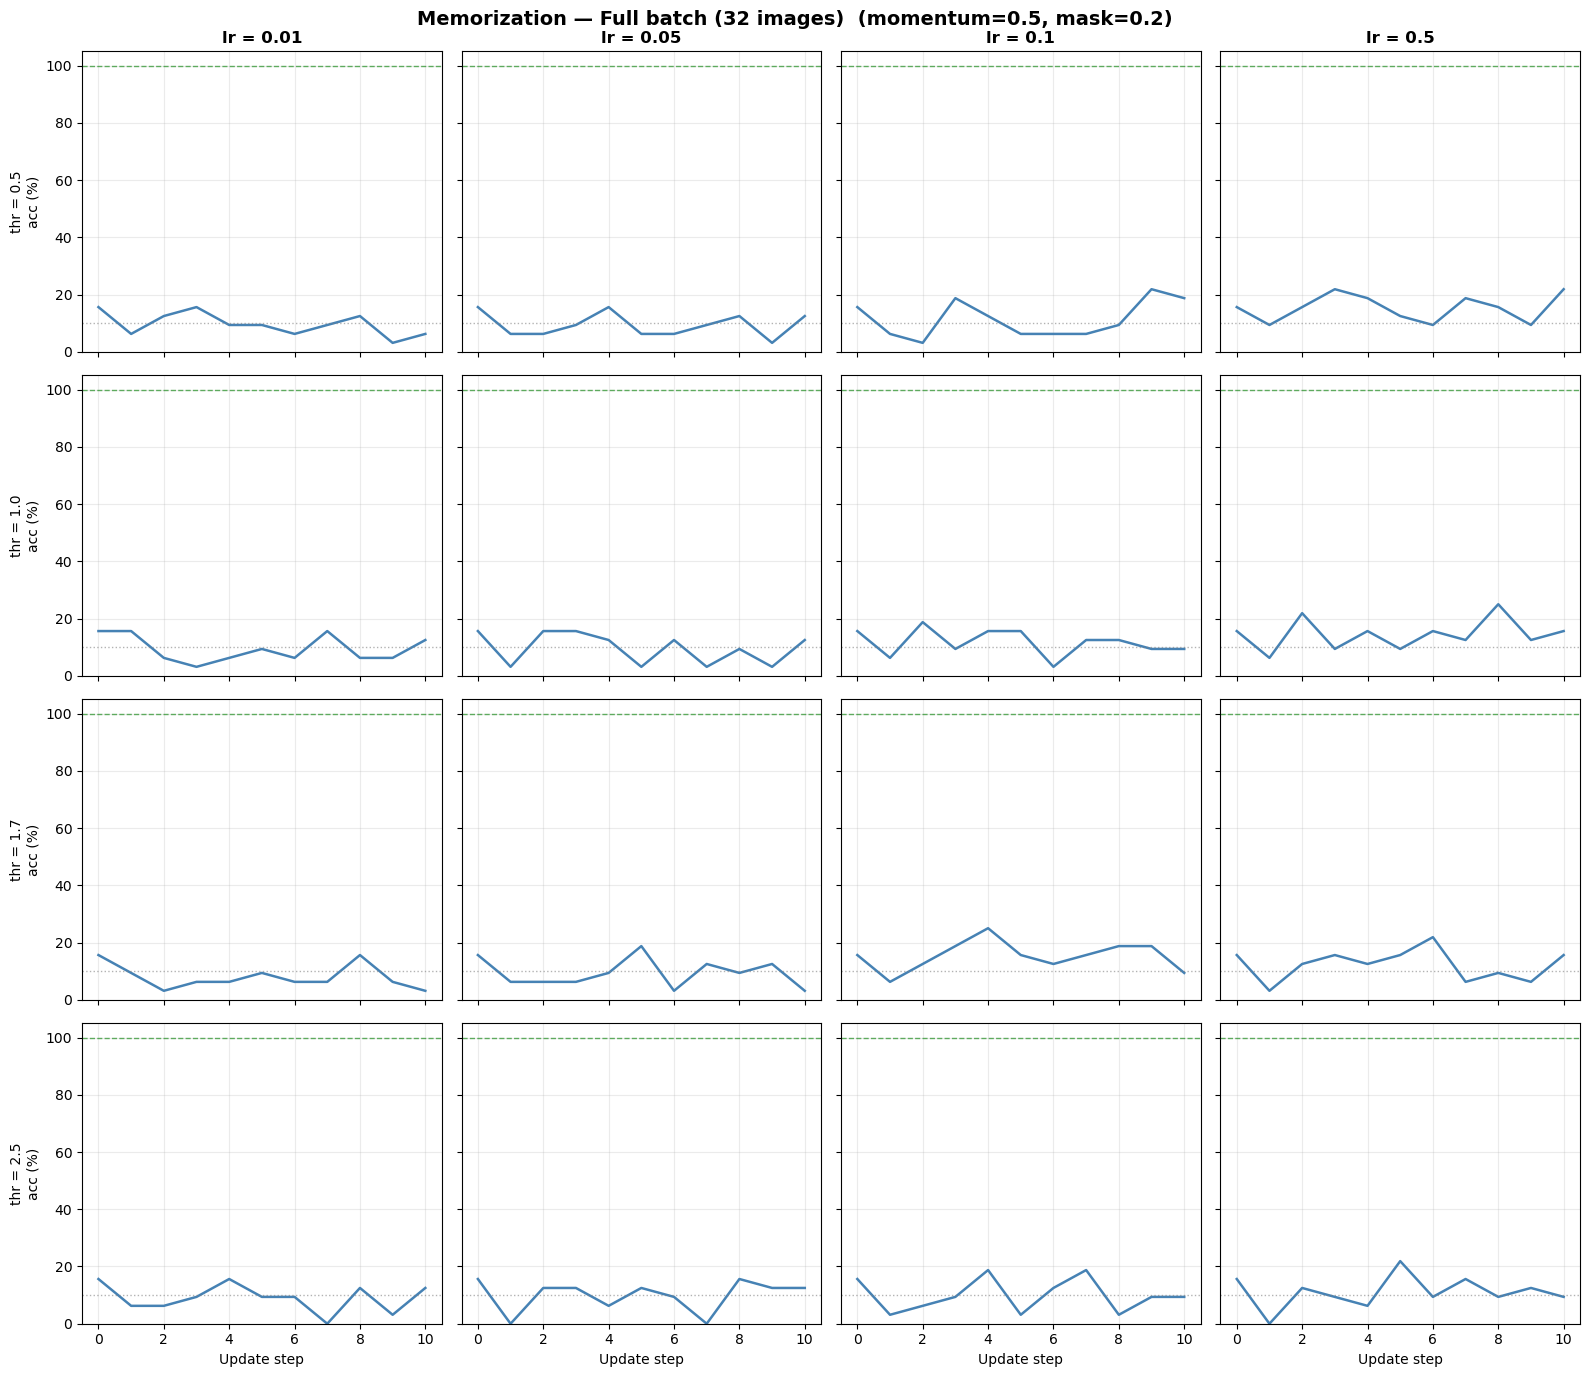

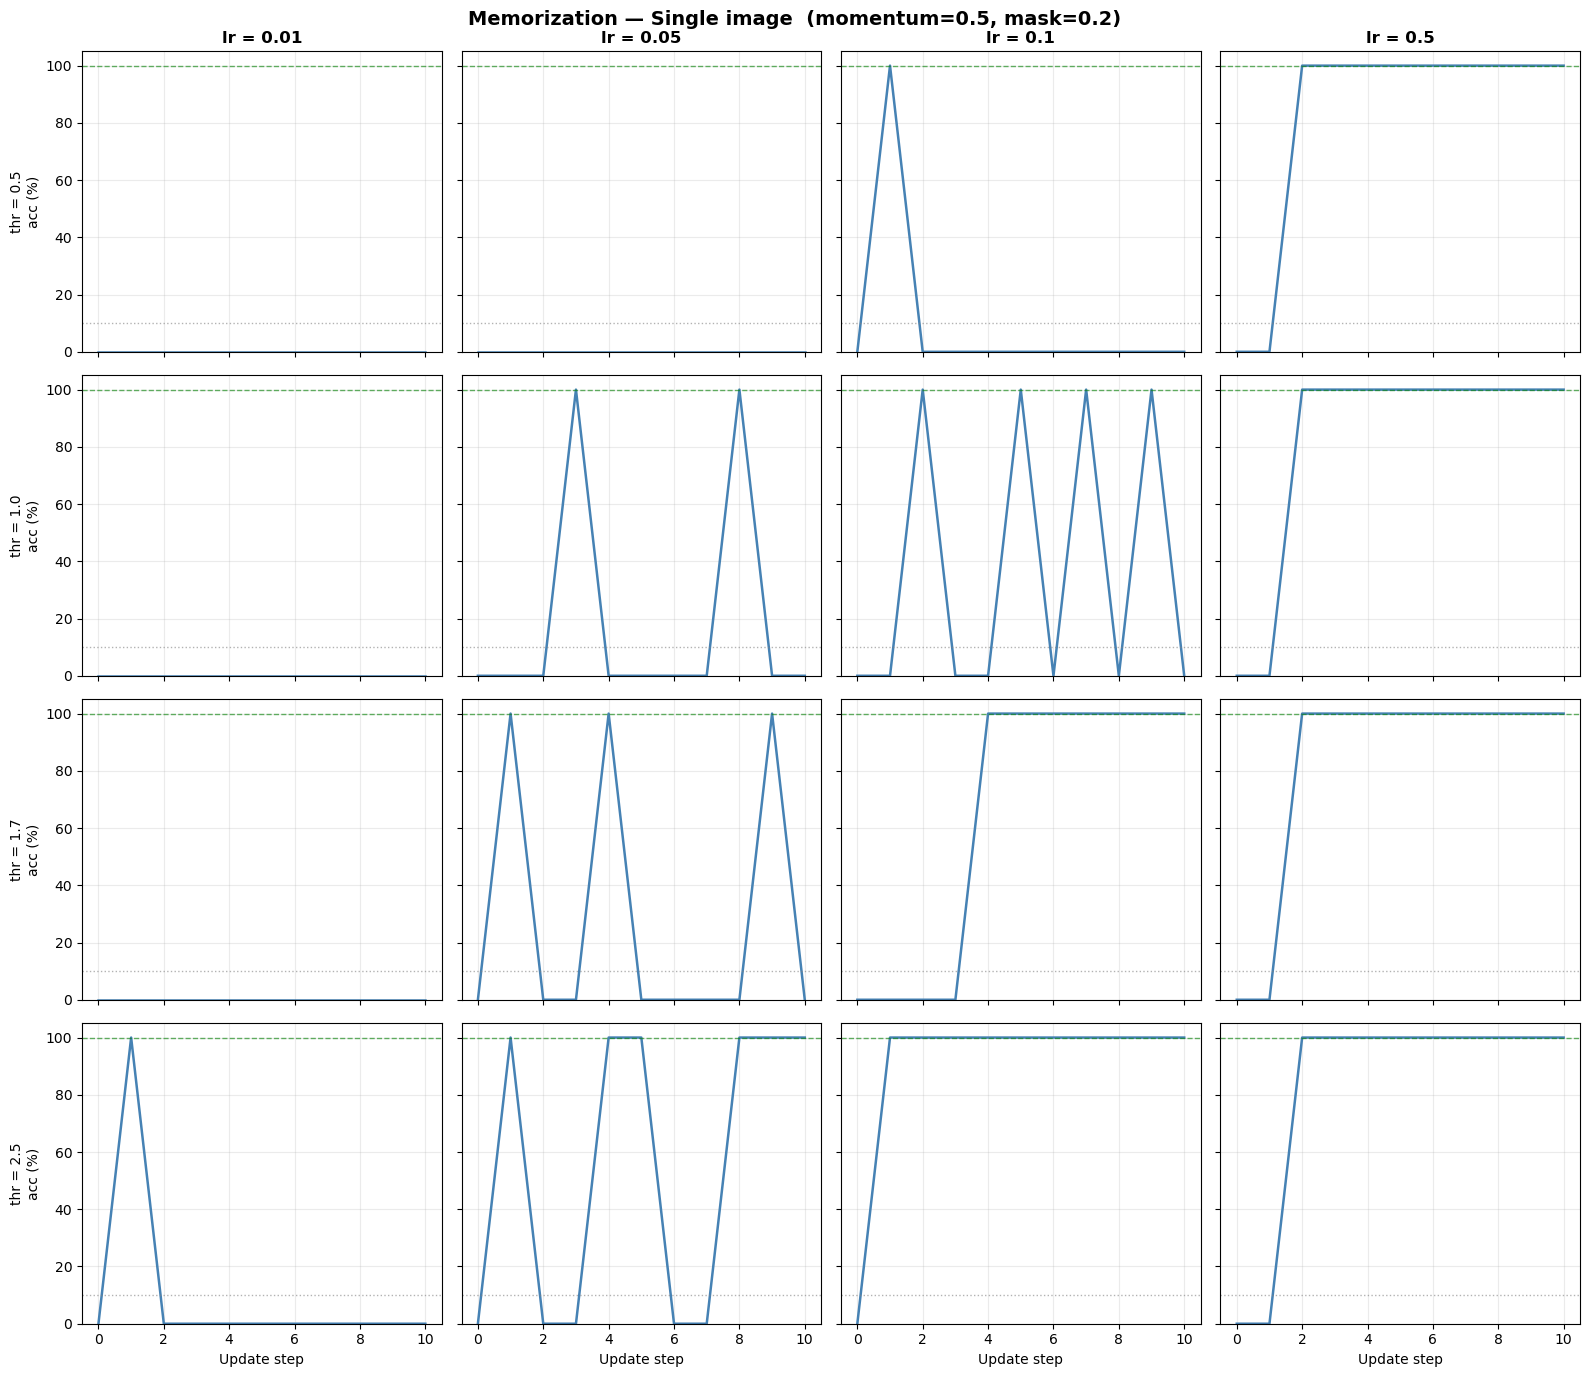

In [19]:
def plot_learning_curves(mode, title):
    """4×4 grid: rows = threshold, cols = lr. Accuracy vs update step."""
    fig, axes = plt.subplots(
        len(THRESHOLDS), len(LRS),
        figsize=(4 * len(LRS), 3.5 * len(THRESHOLDS)),
        sharex=True, sharey=True,
    )
    chance = 100.0 / 10  # 10-class problem

    for r, thr in enumerate(THRESHOLDS):
        for c, lr in enumerate(LRS):
            ax = axes[r, c]
            hist = results[(mode, thr, lr)]
            steps = list(range(len(hist)))
            ax.plot(steps, hist, color="steelblue", linewidth=1.8)
            ax.axhline(100, color="green",  lw=1, ls="--", alpha=0.6, label="100%")
            ax.axhline(chance, color="gray", lw=1, ls=":",  alpha=0.6, label="chance")
            ax.set_ylim(0, 105)
            ax.grid(True, alpha=0.25)
            if r == 0:
                ax.set_title(f"lr = {lr}", fontweight="bold")
            if c == 0:
                ax.set_ylabel(f"thr = {thr}\nacc (%)")
            if r == len(THRESHOLDS) - 1:
                ax.set_xlabel("Update step")

    fig.suptitle(f"Memorization — {title}  (momentum={MOMENTUM}, mask={MASK_PROB})",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_learning_curves("batch",  "Full batch (32 images)")
plot_learning_curves("single", "Single image")


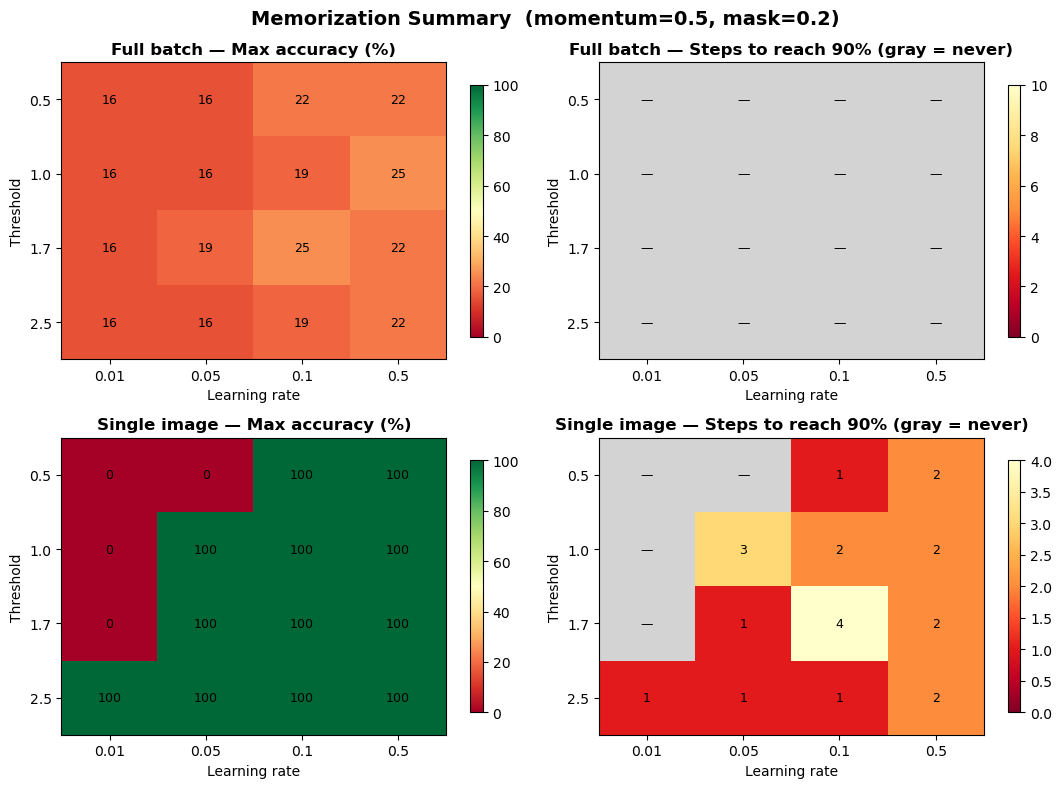

In [20]:
def make_summary_heatmaps():
    """Two rows (batch / single), two columns (max acc / steps to 90%)."""
    THRESHOLD_90 = 90.0

    fig, axes = plt.subplots(2, 2, figsize=(11, 8))
    modes = [("batch", "Full batch"), ("single", "Single image")]

    for row, (mode, mode_label) in enumerate(modes):
        # Build matrices indexed (threshold row, lr col)
        max_acc_mat   = np.zeros((len(THRESHOLDS), len(LRS)))
        steps_90_mat  = np.full((len(THRESHOLDS), len(LRS)), np.nan)  # NaN = never reached

        for r, thr in enumerate(THRESHOLDS):
            for c, lr in enumerate(LRS):
                hist = results[(mode, thr, lr)]
                max_acc_mat[r, c] = max(hist)
                reached = [s for s, a in enumerate(hist) if a >= THRESHOLD_90]
                if reached:
                    steps_90_mat[r, c] = reached[0]

        lr_labels  = [str(lr)  for lr  in LRS]
        thr_labels = [str(thr) for thr in THRESHOLDS]

        # Max accuracy heatmap
        ax = axes[row, 0]
        im = ax.imshow(max_acc_mat, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
        ax.set_xticks(range(len(LRS)));       ax.set_xticklabels(lr_labels)
        ax.set_yticks(range(len(THRESHOLDS))); ax.set_yticklabels(thr_labels)
        ax.set_xlabel("Learning rate"); ax.set_ylabel("Threshold")
        ax.set_title(f"{mode_label} — Max accuracy (%)", fontweight="bold")
        for r in range(len(THRESHOLDS)):
            for c in range(len(LRS)):
                ax.text(c, r, f"{max_acc_mat[r,c]:.0f}", ha="center", va="center",
                        fontsize=9, color="black")
        plt.colorbar(im, ax=ax, shrink=0.85)

        # Steps-to-90% heatmap
        ax = axes[row, 1]
        valid = steps_90_mat[~np.isnan(steps_90_mat)]
        vmax  = valid.max() if len(valid) > 0 else N_UPDATES_MAX
        # Use a masked array so NaN cells show as gray
        masked = np.ma.masked_invalid(steps_90_mat)
        cmap_steps = plt.cm.YlOrRd_r.copy()
        cmap_steps.set_bad(color="lightgray")
        im2 = ax.imshow(masked, cmap=cmap_steps, vmin=0, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(LRS)));       ax.set_xticklabels(lr_labels)
        ax.set_yticks(range(len(THRESHOLDS))); ax.set_yticklabels(thr_labels)
        ax.set_xlabel("Learning rate"); ax.set_ylabel("Threshold")
        ax.set_title(f"{mode_label} — Steps to reach 90% (gray = never)", fontweight="bold")
        for r in range(len(THRESHOLDS)):
            for c in range(len(LRS)):
                val = steps_90_mat[r, c]
                txt = "—" if np.isnan(val) else str(int(val))
                ax.text(c, r, txt, ha="center", va="center", fontsize=9, color="black")
        plt.colorbar(im2, ax=ax, shrink=0.85)

    fig.suptitle(f"Memorization Summary  (momentum={MOMENTUM}, mask={MASK_PROB})",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


make_summary_heatmaps()
